<a href="https://colab.research.google.com/github/abdillahlatief/credit-default-prediction/blob/main/UTS_PMML_M_Abdillah_L_035.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS Prediksi Modern & Machine Learning
## Experiment Challenge: Credit Default Prediction

## **Muhammad Abdillah Latief (2404220035)**

Dataset: *Default of Credit Card Clients* (UCI/Kaggle), 30.000 nasabah kartu kredit di Taiwan.
Target: `default.payment.next.month` (0 = tidak default, 1 = default).
Metrik utama: **F1-score** (kelas positif = default). Metrik pendukung: Accuracy, Precision, Recall.
Evaluasi: **5-fold Stratified Cross Validation** pada training set + evaluasi pada test set.

In [ ]:
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

In [ ]:
DATA_PATH = 'UCI_Credit_Card.csv'
if not os.path.exists(DATA_PATH):
    from google.colab import files
    files.upload()
df = pd.read_csv(DATA_PATH)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Experiment 0 — Data Understanding & Preparation

### 0.1 Dimensi, struktur, dan tipe data

In [ ]:
print('Dimensi dataset:', df.shape)
df.info()

Dimensi dataset: (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BI

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


### 0.2 Variabel target, missing value, dan duplicate

In [ ]:
TARGET = 'default.payment.next.month'
print('Variabel target:', TARGET)
print('\nTotal missing value :', int(df.isna().sum().sum()))
print('Duplicate (semua kolom)       :', int(df.duplicated().sum()))
print('Duplicate (tanpa kolom ID)    :', int(df.drop(columns='ID').duplicated().sum()))

Variabel target: default.payment.next.month

Total missing value : 0
Duplicate (semua kolom)       : 0
Duplicate (tanpa kolom ID)    : 35


**Temuan:** tidak ada missing value. Duplicate pada seluruh kolom = 0 (karena `ID` unik). Setelah `ID` diabaikan ada beberapa baris dengan nilai identik; baris-baris ini **dipertahankan** karena
bisa saja merupakan nasabah berbeda dengan profil yang kebetulan sama (tidak ada bukti kesalahan input), dan jumlahnya sangat kecil.

### 0.3 Pemeriksaan nilai tidak sesuai / tidak wajar

In [ ]:
for c in ['SEX', 'EDUCATION', 'MARRIAGE']:
    print(c, df[c].value_counts().sort_index().to_dict())
print()
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
print('Nilai unik PAY_*:', sorted(pd.unique(df[pay_cols].values.ravel())))
print('AGE   min/max:', df.AGE.min(), df.AGE.max())
print('LIMIT_BAL min/max:', df.LIMIT_BAL.min(), df.LIMIT_BAL.max())
bill_cols = [f'BILL_AMT{i}' for i in range(1,7)]
amt_cols = [f'PAY_AMT{i}' for i in range(1,7)]
print('Jumlah BILL_AMT negatif :', int((df[bill_cols] < 0).sum().sum()), '(wajar: kelebihan bayar / kredit)')
print('Jumlah PAY_AMT negatif  :', int((df[amt_cols] < 0).sum().sum()))

SEX {1: 11888, 2: 18112}
EDUCATION {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
MARRIAGE {0: 54, 1: 13659, 2: 15964, 3: 323}

Nilai unik PAY_*: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
AGE   min/max: 21 79
LIMIT_BAL min/max: 10000.0 1000000.0
Jumlah BILL_AMT negatif : 3932 (wajar: kelebihan bayar / kredit)
Jumlah PAY_AMT negatif  : 0


**Temuan & keputusan:**
- `EDUCATION` seharusnya hanya 1–4 (1 = graduate school, 2 = university, 3 = high school, 4 = others), tetapi ada kode **0, 5, 6** yang tidak terdokumentasi → digabung ke kategori `4` (others).
- `MARRIAGE` seharusnya 1–3 (1 = married, 2 = single, 3 = others), tetapi ada kode **0** → digabung ke kategori `3` (others).
- `PAY_*` bernilai -2, -1, 0 (tepat waktu/tidak ada tagihan) hingga 8 (terlambat 8 bulan) — ini kode status yang valid, **tidak diubah**.
- `BILL_AMT*` negatif = kelebihan bayar, nilai yang wajar secara bisnis, **tidak dihapus**. `AGE` dan `LIMIT_BAL` berada pada rentang wajar.

Penggabungan kategori ini adalah pemetaan tetap (aturan berdasarkan dokumentasi dataset, bukan statistik yang dihitung dari data), sehingga aman dilakukan sebelum split dan **tidak menimbulkan data leakage**.

In [ ]:
df_clean = df.copy()
df_clean['EDUCATION'] = df_clean['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df_clean['MARRIAGE'] = df_clean['MARRIAGE'].replace({0: 3})
print(df_clean['EDUCATION'].value_counts().sort_index().to_dict())
print(df_clean['MARRIAGE'].value_counts().sort_index().to_dict())

{1: 10585, 2: 14030, 3: 4917, 4: 468}
{1: 13659, 2: 15964, 3: 377}


### 0.4 Distribusi variabel target

default.payment.next.month
0    23364
1     6636
default.payment.next.month
0    77.88
1    22.12


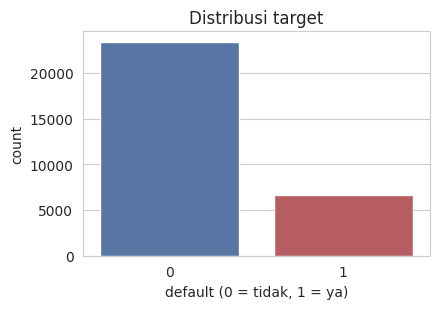

In [ ]:
vc = df_clean[TARGET].value_counts()
print(vc.to_string()); print((vc / len(df_clean) * 100).round(2).to_string())
plt.figure(figsize=(4.5, 3.2))
sns.countplot(x=TARGET, data=df_clean, palette=['#4C72B0', '#C44E52'])
plt.title('Distribusi target'); plt.xlabel('default (0 = tidak, 1 = ya)'); plt.tight_layout(); plt.show()

**Temuan:** kelas tidak seimbang (sekitar 78% tidak default vs 22% default). Karena itu *Accuracy* bisa menyesatkan, dan F1-score pada kelas default dipilih sebagai metrik utama.

### 0.5 Predictor, target, dan train-test split

In [ ]:
X = df_clean.drop(columns=['ID', TARGET])   # ID tidak dipakai sebagai predictor
y = df_clean[TARGET]
print('Jumlah predictor:', X.shape[1]); print(list(X.columns))

# Split SEBELUM preprocessing/training; stratify agar proporsi kelas terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print('\nTrain:', X_train.shape, '| Test:', X_test.shape)
print('Proporsi default  train:', round(y_train.mean(), 4), '| test:', round(y_test.mean(), 4))

cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
num_cols = [c for c in X.columns if c not in cat_cols]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Jumlah predictor: 23
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Train: (24000, 23) | Test: (6000, 23)
Proporsi default  train: 0.2212 | test: 0.2212


**Keputusan preprocessing (Experiment 0):** 80% train / 20% test (stratified, `random_state=42`).
Seluruh proses yang *belajar dari data* (scaling, encoding) dilakukan di dalam **Pipeline**, sehingga pada setiap fold CV hanya di-fit pada data training fold tersebut → tidak ada data leakage.
Test set hanya dipakai untuk evaluasi akhir.

## Fungsi bantu evaluasi (prosedur sama untuk semua model)

In [ ]:
results = []   # menyimpan semua hasil eksperimen

def evaluate(exp, name, estimator, store=True):
    cv_f1 = cross_val_score(estimator, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)
    estimator.fit(X_train, y_train)
    pred = estimator.predict(X_test)
    row = {'Experiment': exp, 'Model': name,
           'CV F1': cv_f1.mean(), 'CV F1 Std': cv_f1.std(),
           'Test Accuracy': accuracy_score(y_test, pred),
           'Test Precision': precision_score(y_test, pred),
           'Test Recall': recall_score(y_test, pred),
           'Test F1': f1_score(y_test, pred)}
    if store: results.append(row)
    return row, estimator

COLS = ['Model', 'CV F1', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']
def show(rows): return pd.DataFrame(rows)[COLS].round(4)

## Experiment 1 — Baseline Model
Logistic Regression dengan data apa adanya setelah pembersihan kode tidak valid (tanpa scaling, tanpa encoding, tanpa penanganan imbalance).

In [ ]:
base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
row1, model1 = evaluate(1, 'Logistic Regression (baseline)', base)
show([row1])

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression (baseline),0.3367,0.8082,0.6648,0.2675,0.3815


## Experiment 2 — Preprocessing
Tiga varian preprocessing dibandingkan terhadap baseline (model tetap Logistic Regression):
- **2A** feature scaling (StandardScaler pada fitur numerik)
- **2B** scaling + One-Hot Encoding untuk `SEX`, `EDUCATION`, `MARRIAGE` (variabel nominal)
- **2C** 2B + `class_weight='balanced'` untuk menangani imbalance kelas

Varian dengan **CV F1 tertinggi** dipakai sebagai preprocessing untuk eksperimen berikutnya.

In [ ]:
def make_prep(encode):
    if encode:
        return ColumnTransformer([('num', StandardScaler(), num_cols),
                                  ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)])
    return ColumnTransformer([('num', StandardScaler(), num_cols)], remainder='passthrough')

variants = {
    '2A: scaling':                  (False, None),
    '2B: scaling + encoding':       (True,  None),
    '2C: scaling + encoding + class_weight': (True, 'balanced'),
}
var_rows, var_models = {}, {}
for name, (enc, cw) in variants.items():
    pipe = Pipeline([('prep', make_prep(enc)),
                     ('model', LogisticRegression(max_iter=1000, class_weight=cw, random_state=RANDOM_STATE))])
    r, m = evaluate(2, f'LR {name}', pipe, store=False)
    var_rows[name], var_models[name] = r, m

cmp2 = show([row1] + list(var_rows.values()))
cmp2

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression (baseline),0.3367,0.8082,0.6648,0.2675,0.3815
1,LR 2A: scaling,0.3659,0.8083,0.6895,0.2427,0.3590
2,LR 2B: scaling + encoding,0.3641,0.8088,0.6923,0.2442,0.3610
3,LR 2C: scaling + encoding + class_weight,0.4812,0.6787,0.3679,0.6307,0.4647


In [ ]:
best_var = max(var_rows, key=lambda k: var_rows[k]['CV F1'])
ENCODE, CW = variants[best_var]
print('Varian preprocessing terpilih (CV F1 tertinggi):', best_var)
results.append(var_rows[best_var] | {'Model': f'Logistic Regression + preprocessing ({best_var})'})

delta = pd.DataFrame({
    'Metrik': ['CV F1', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1'],
    'Baseline (Exp 1)': [row1[k] for k in ['CV F1','Test Accuracy','Test Precision','Test Recall','Test F1']],
    'Exp 2 (terpilih)': [var_rows[best_var][k] for k in ['CV F1','Test Accuracy','Test Precision','Test Recall','Test F1']]})
delta['Selisih'] = delta['Exp 2 (terpilih)'] - delta['Baseline (Exp 1)']
delta.round(4)

Varian preprocessing terpilih (CV F1 tertinggi): 2C: scaling + encoding + class_weight


,Metrik,Baseline (Exp 1),Exp 2 (terpilih),Selisih
0,CV F1,0.3367,0.4812,0.1446
1,Test Accuracy,0.8082,0.6787,-0.1295
2,Test Precision,0.6648,0.3679,-0.2969
3,Test Recall,0.2675,0.6307,0.3632
4,Test F1,0.3815,0.4647,0.0832


**Interpretasi:** lihat tabel di atas. Perbedaan antara varian 2A/2B terhadap baseline menunjukkan efek murni scaling dan encoding, sedangkan 2C menunjukkan efek penanganan imbalance
(umumnya menaikkan Recall dan F1 dengan mengorbankan Precision/Accuracy). Kesimpulan formal dituliskan pada PDF Final Analysis.

## Experiment 3 — Model Comparison
Logistic Regression, Decision Tree, dan Random Forest dengan **preprocessing terpilih dari Experiment 2** dan prosedur evaluasi yang sama (5-fold CV pada train + test set).
Model default (belum di-tuning) digunakan agar perbandingan adil.

In [ ]:
def build(model):
    return Pipeline([('prep', make_prep(ENCODE)), ('model', model)])

models3 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight=CW, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(class_weight=CW, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight=CW, random_state=RANDOM_STATE, n_jobs=-1),
}
rows3, fitted3 = {}, {}
for name, mdl in models3.items():
    r, m = evaluate(3, name, build(mdl), store=False)
    rows3[name], fitted3[name] = r, m
show(list(rows3.values()))

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,0.4812,0.6787,0.3679,0.6307,0.4647
1,Decision Tree,0.3931,0.7272,0.3854,0.3926,0.3890
2,Random Forest,0.4611,0.8115,0.6433,0.3316,0.4376


In [ ]:
best3 = max(rows3, key=lambda k: rows3[k]['CV F1'])
print('Model terbaik Experiment 3 (berdasarkan CV F1):', best3)
results.append(rows3[best3] | {'Model': f'{best3} (terbaik Exp 3)'})
all3 = pd.DataFrame(rows3.values())
all3.to_csv('exp3_all_models.csv', index=False)

Model terbaik Experiment 3 (berdasarkan CV F1): Logistic Regression


## Experiment 4 — Hyperparameter Tuning
GridSearchCV (5-fold, scoring = F1) pada model terbaik dari Experiment 3.

In [ ]:
param_grids = {
    'Logistic Regression': {'model__C': [0.01, 0.1, 1, 10, 100],
                            'model__penalty': ['l1', 'l2'],
                            'model__solver': ['liblinear']},
    'Decision Tree': {'model__max_depth': [3, 5, 7, 10, None],
                      'model__min_samples_leaf': [1, 10, 50],
                      'model__criterion': ['gini', 'entropy']},
    'Random Forest': {'model__n_estimators': [100, 200],
                      'model__max_depth': [8, 12, None],
                      'model__min_samples_leaf': [5, 20]},
}
grid = GridSearchCV(build(models3[best3]), param_grids[best3], scoring='f1', cv=skf, n_jobs=-1, refit=True)
grid.fit(X_train, y_train)
print('Model yang di-tuning     :', best3)
print('Hyperparameter yang diuji:', param_grids[best3])
print('Kombinasi terbaik        :', grid.best_params_)
print('Best CV F1-score         :', round(grid.best_score_, 4))

Model yang di-tuning     : Logistic Regression
Hyperparameter yang diuji: {'model__C': [0.01, 0.1, 1, 10, 100], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear']}
Kombinasi terbaik        : {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV F1-score         : 0.4839


In [ ]:
pred4 = grid.predict(X_test)
row4 = {'Experiment': 4, 'Model': f'{best3} (tuned)', 'CV F1': grid.best_score_,
        'CV F1 Std': grid.cv_results_['std_test_score'][grid.best_index_],
        'Test Accuracy': accuracy_score(y_test, pred4), 'Test Precision': precision_score(y_test, pred4),
        'Test Recall': recall_score(y_test, pred4), 'Test F1': f1_score(y_test, pred4)}
results.append(row4)
before_after = show([rows3[best3] | {'Model': f'{best3} - sebelum tuning'}, row4 | {'Model': f'{best3} - setelah tuning'}])
before_after

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression - sebelum tuning,0.4812,0.6787,0.3679,0.6307,0.4647
1,Logistic Regression - setelah tuning,0.4839,0.6812,0.3704,0.6307,0.4667


In [ ]:
cvres = pd.DataFrame(grid.cv_results_)
cvres[[c for c in cvres.columns if c.startswith('param_')] + ['mean_test_score', 'std_test_score', 'rank_test_score']] \
    .sort_values('rank_test_score').head(10).round(4)

,param_model__C,param_model__penalty,param_model__solver,mean_test_score,std_test_score,rank_test_score
2,0.10,l1,liblinear,0.4839,0.0123,1
1,0.01,l2,liblinear,0.4833,0.0124,2
5,1.00,l2,liblinear,0.4816,0.0114,3
8,100.00,l1,liblinear,0.4815,0.0115,4
7,10.00,l2,liblinear,0.4814,0.0115,5
9,100.00,l2,liblinear,0.4814,0.0115,6
6,10.00,l1,liblinear,0.4814,0.0116,7
3,0.10,l2,liblinear,0.4811,0.0113,8
4,1.00,l1,liblinear,0.4810,0.0114,9
0,0.01,l1,liblinear,0.4803,0.0115,10


## Experiment 5 — Advanced Model (XGBoost)
XGBoost (gradient boosting). `scale_pos_weight` dihitung **hanya dari y_train** (rasio kelas negatif : positif) bila preprocessing terpilih memakai class weighting.
Preprocessing sama dengan eksperimen sebelumnya, dengan prosedur evaluasi yang sama.

In [ ]:
spw = (y_train == 0).sum() / (y_train == 1).sum() if CW == 'balanced' else 1.0
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8,
                    colsample_bytree=0.8, scale_pos_weight=spw, eval_metric='logloss',
                    random_state=RANDOM_STATE, n_jobs=-1)
row5, model5 = evaluate(5, 'XGBoost', build(xgb))
print('scale_pos_weight =', round(spw, 3))
show([row4, row5])

scale_pos_weight = 3.521


,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression (tuned),0.4839,0.6812,0.3704,0.6307,0.4667
1,XGBoost,0.5398,0.7637,0.4738,0.6202,0.5372


## Ringkasan Seluruh Eksperimen

In [ ]:
summary = pd.DataFrame(results)
summary.insert(0, 'Exp', [1, 2, 3, 4, 5])
summary = summary[['Exp', 'Model', 'CV F1', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']]
summary.to_csv('summary_results.csv', index=False)
summary.round(4)

,Exp,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,1,Logistic Regression (baseline),0.3367,0.8082,0.6648,0.2675,0.3815
1,2,Logistic Regression + preprocessing (2C: scali...,0.4812,0.6787,0.3679,0.6307,0.4647
2,3,Logistic Regression (terbaik Exp 3),0.4812,0.6787,0.3679,0.6307,0.4647
3,4,Logistic Regression (tuned),0.4839,0.6812,0.3704,0.6307,0.4667
4,5,XGBoost,0.5398,0.7637,0.4738,0.6202,0.5372


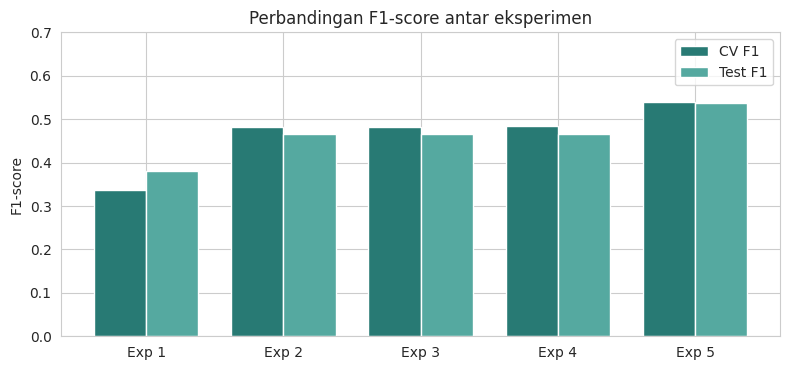

In [ ]:
plt.figure(figsize=(8, 3.8))
x = np.arange(len(summary)); w = 0.38
plt.bar(x - w/2, summary['CV F1'], w, label='CV F1', color='#287A74')
plt.bar(x + w/2, summary['Test F1'], w, label='Test F1', color='#55A9A0')
plt.xticks(x, [f'Exp {e}' for e in summary['Exp']]); plt.ylabel('F1-score'); plt.ylim(0, 0.7)
plt.title('Perbandingan F1-score antar eksperimen'); plt.legend(); plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=200); plt.show()

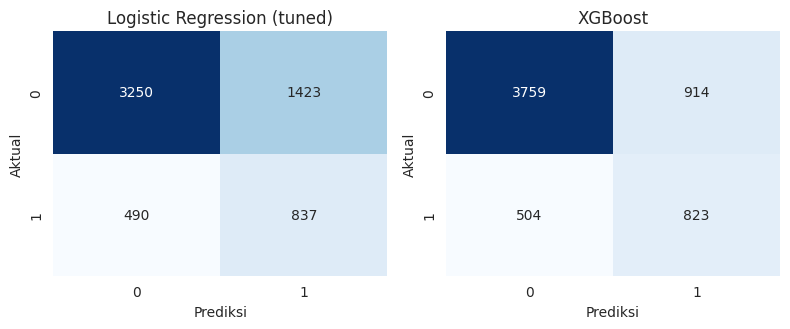

In [ ]:
# Confusion matrix model Exp 4 dan Exp 5 pada test set
fig, ax = plt.subplots(1, 2, figsize=(8, 3.4))
for a, (title, mdl) in zip(ax, [(f'{best3} (tuned)', grid), ('XGBoost', model5)]):
    cm = confusion_matrix(y_test, mdl.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=a)
    a.set_title(title); a.set_xlabel('Prediksi'); a.set_ylabel('Aktual')
plt.tight_layout(); plt.savefig('confusion_matrices.png', dpi=200); plt.show()

In [ ]:
# Ranking akhir berdasarkan CV F1 (kriteria utama) — kandidat: Exp 3 (terbaik), Exp 4, Exp 5
print(summary.sort_values('CV F1', ascending=False)[['Exp','Model','CV F1','Test F1']].round(4).to_string(index=False))

 Exp                                                                       Model  CV F1  Test F1
   5                                                                     XGBoost 0.5398   0.5372
   4                                                 Logistic Regression (tuned) 0.4839   0.4667
   3                                         Logistic Regression (terbaik Exp 3) 0.4812   0.4647
   2 Logistic Regression + preprocessing (2C: scaling + encoding + class_weight) 0.4812   0.4647
   1                                              Logistic Regression (baseline) 0.3367   0.3815
